## Objectif
Construire un pipeline commun de préparation des données (nettoyage, feature engineering, split, preprocessing)

**Dataset :** Bank Marketing (bank-additional-full.csv): La version enrichie du dataset (Moro et al., 2014) est utilisée.
La variable `duration` est exclue car elle n’est connue qu’après l’appel et introduirait une fuite d’information
dans un cadre prédictif réaliste.

**Tâche :** Classification supervisée binaire

In [2]:
# Importation des bibliothèques nécessaires
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage des DataFrames
pd.set_option('display.max_columns', 200)
pd.set_option ("display.width", 120)

# Chargement des données
ROOT = Path ("..")
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
DATA_PATH = ROOT / "data" / "raw" / "bank-additional-full.csv"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 1. Chargement des données

On charge le fichier `bank-additional-full.csv` puis on vérifie :
- la dimension du dataset,
- les types de variables,
- la présence de valeurs manquantes,
- la présence éventuelle de doublons.

In [3]:
from src.io_utils import charger_dataset
from src.controle_qualite import resume_qualite, detecter_doublons
from src.preparation import nettoyer_colonnes, retirer_duration
from src.visualisation import (
    plot_cible_repartition,
    plot_distribution_age,
    plot_heatmap_correlation
)

In [4]:
df = charger_dataset(DATA_PATH, sep=";")
df.shape, df.head()

((41188, 21),
    age        job  marital    education  default housing loan    contact month day_of_week  duration  campaign  pdays  \
 0   56  housemaid  married     basic.4y       no      no   no  telephone   may         mon       261         1    999   
 1   57   services  married  high.school  unknown      no   no  telephone   may         mon       149         1    999   
 2   37   services  married  high.school       no     yes   no  telephone   may         mon       226         1    999   
 3   40     admin.  married     basic.6y       no      no   no  telephone   may         mon       151         1    999   
 4   56   services  married  high.school       no      no  yes  telephone   may         mon       307         1    999   
 
    previous     poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y  
 0         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no  
 1         0  nonexistent           1.1          9

In [5]:
# Informations générales sur le DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Contrôle de la qualité des données
resume_qualite(df)

Dimensions : 41188 lignes × 21 colonnes
Valeurs manquantes : aucune (NaN) détectée.
Modalité "unknown" : taux par variable (catégorielles)
    variable  %_unknown
3    default      20.87
2  education       4.20
4    housing       2.40
5       loan       2.40
0        job       0.80
1    marital       0.19

Répartition de la cible :
     effectif  proportion
y                        
no      36548      0.8873
yes      4640      0.1127


,nb_manquants,%_manquants


In [7]:
# Détection des doublons
n_dup = detecter_doublons(df)
print(f"Nombre de doublons : {n_dup}")

Nombre de doublons : 12


In [8]:
# Suppression des doublons
df = df.drop_duplicates()
print(f"Dimensions après suppression des doublons : {df.shape}")

Dimensions après suppression des doublons : (41176, 21)


## Structure des variables

On distingue :
- variables numériques,
- variables catégorielles,
- variable cible `y`.

Cette étape sert à préparer les traitements ultérieurs (encodage, standardisation).

In [9]:
# Nettoyage des noms de colonnes
df = nettoyer_colonnes(df)
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week',
       'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx',
       'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [10]:
# Liste des variables numériques et catégorielles
cible = "y"

variables_numeriques = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categorielles = df.select_dtypes(include=["object"]).columns.tolist()

# Retrait de la cible des catégorielles si elle y est
if cible in variables_categorielles:
    variables_categorielles.remove(cible)

variables_numeriques, variables_categorielles

(['age',
  'duration',
  'campaign',
  'pdays',
  'previous',
  'emp_var_rate',
  'cons_price_idx',
  'cons_conf_idx',
  'euribor3m',
  'nr_employed'],
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'])

**Remarque :** certaines variables catégorielles contiennent la modalité `"unknown"`.
Dans ce projet, cette modalité est conservée comme une catégorie explicite.

## 3. Analyse de la variable cible

On examine la répartition de `y` afin d’identifier un éventuel déséquilibre de classes.
Dans ce contexte, l’accuracy seule n’est pas suffisante pour juger la performance d’un modèle.

In [33]:
# Répartition de la cible
df[cible].value_counts(), df[cible].value_counts(normalize=True).round(4)

(y
 no     36537
 yes     4639
 Name: count, dtype: int64,
 y
 no     0.8873
 yes    0.1127
 Name: proportion, dtype: float64)

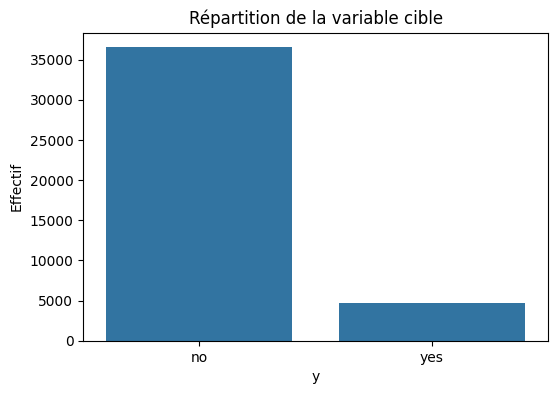

In [34]:
# Visualisation de la répartition de la cible
plot_cible_repartition(df, cible=cible, save_path=FIG_DIR / "cible_repartition.png")


## 4. Analyse descriptive (EDA)

In [11]:
# Statistiques descriptives des variables numériques
df[variables_numeriques].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp_var_rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons_price_idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons_conf_idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr_employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


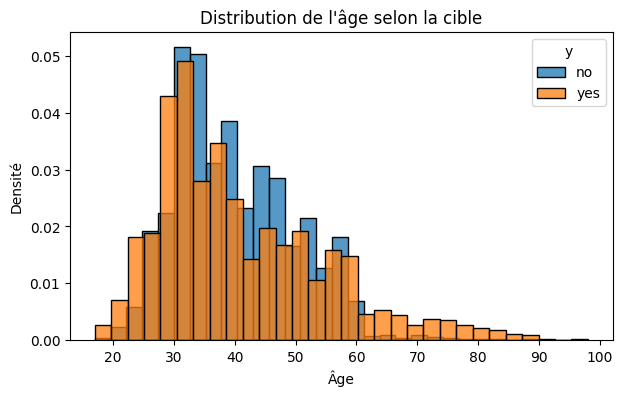

In [12]:
# Distribution de l'âge
plot_distribution_age(df, cible=cible, save_path=FIG_DIR / "distribution_age.png")

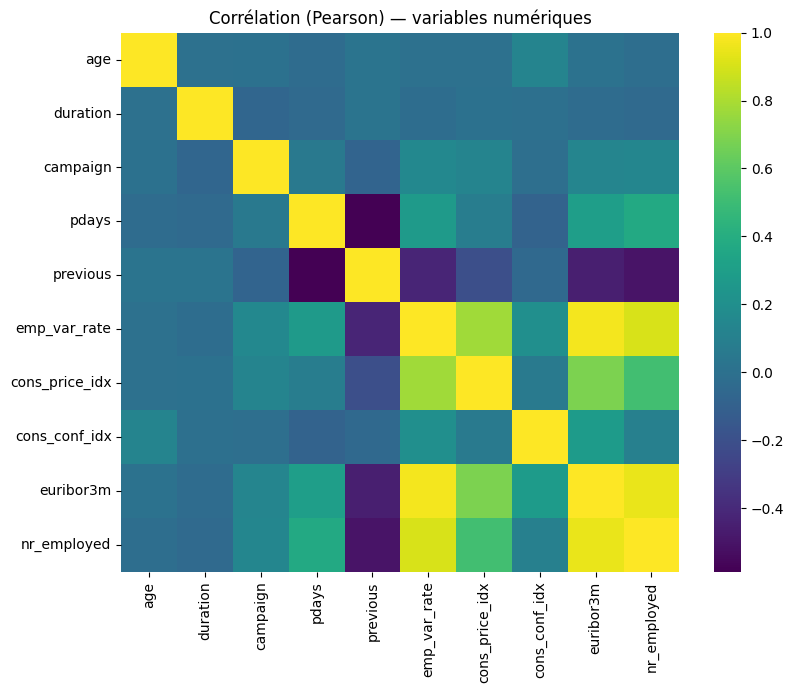

In [13]:
# Coorélations entre variables numériques et heatmap
plot_heatmap_correlation(df, variables_numeriques=variables_numeriques, save_path=FIG_DIR / "heatmap_corr.png")

**Interprétation :**  
On observe des corrélations notables entre certaines variables macroéconomiques, ce qui peut introduire un risque de multicolinéarité dans les modèles linéaires.  
Ce point sera traité lors de la modélisation (régularisation et/ou sélection de variables).

## 5. Exclusion de la variable `duration` (data leakage)

La variable `duration` (durée du dernier appel) est connue après la fin du contact.
Son inclusion introduirait une fuite d’information et biaiserait l’évaluation.
Elle est donc exclue pour conserver un cadre prédictif cohérent.

In [14]:
df = retirer_duration(df)

variables_numeriques = [c for c in variables_numeriques if c != "duration"]
df.shape

(41176, 20)

## 6. Décisions de préparation retenues

À l’issue de l’exploration, les choix suivants sont retenus :

- exclusion de `duration` (fuite d’information),
- conservation de `"unknown"` comme catégorie,
- encodage futur des variables catégorielles (One-Hot Encoding),
- standardisation des variables numériques (modèles linéaires),
- séparation entraînement/test stratifiée compte tenu du déséquilibre.

Le Notebook 2 mettra en place un pipeline de préparation et un premier modèle (régression logistique).

In [15]:
# Sauvegarde du DataFrame avec les modifications apportées
OUT_PATH = ROOT / "data" / "processed" / "bank_clean_step1.parquet"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_parquet(OUT_PATH, index=False)
OUT_PATH

WindowsPath("C:/Users/Etudiant/Documents/cours Algo pour l'apprentissage/Projet_Scoring_bank-marketing/data/processed/bank_clean_step1.parquet")